<a href="https://colab.research.google.com/github/samreenfathima18/guvi-project1/blob/main/PROJECT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/drive/MyDrive/CryptoCast/data/Bitcoin Historical Data (1).csv")

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


In [3]:
print("Shape :", df.shape)

print("\nColumns")
print(df.columns)

print("\nInfo")
df.info()

Shape : (4999, 7)

Columns
Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4999 non-null   object
 1   Price     4999 non-null   object
 2   Open      4999 non-null   object
 3   High      4999 non-null   object
 4   Low       4999 non-null   object
 5   Vol.      4993 non-null   object
 6   Change %  4999 non-null   object
dtypes: object(7)
memory usage: 273.5+ KB


In [4]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6
Change %,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# Date
df["Date"] = pd.to_datetime(df["Date"])

# Sort
df = df.sort_values("Date").reset_index(drop=True)

# Price columns
price_cols = ["Price","Open","High","Low"]

for col in price_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Change %
df["Change %"] = (
    df["Change %"]
    .str.replace("%","",regex=False)
    .astype(float)
)

# Volume
def convert_volume(x):

    if pd.isna(x):
        return np.nan

    x = str(x).upper()

    if x == "-":
        return np.nan

    if x.endswith("K"):
        return float(x[:-1])*1000

    if x.endswith("M"):
        return float(x[:-1])*1000000

    if x.endswith("B"):
        return float(x[:-1])*1000000000

    return float(x)

df["Vol."] = df["Vol."].apply(convert_volume)

df["Vol."] = df["Vol."].ffill().bfill()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      4999 non-null   datetime64[ns]
 1   Price     4999 non-null   float64       
 2   Open      4999 non-null   float64       
 3   High      4999 non-null   float64       
 4   Low       4999 non-null   float64       
 5   Vol.      4999 non-null   float64       
 6   Change %  4999 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 273.5 KB


In [ ]:
first_120 = df.head(120)

print("Unique Prices:", first_120["Price"].nunique())

print(first_120["Price"].value_counts().sort_index())

Unique Prices: 4
Price
0.1    100
0.2     14
0.3      5
0.4      1
Name: count, dtype: int64


In [ ]:
df = df.iloc[120:].reset_index(drop=True)

print(df.shape)

(4879, 7)


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,4879,2017-07-20 00:00:00,2010-11-15 00:00:00,2014-03-18 12:00:00,2017-07-20 00:00:00,2020-11-20 12:00:00,2024-03-24 00:00:00,NaN
Price,4879.0,11078.210637,0.2,238.25,2747.0,16604.2,73066.3,15994.470383
Open,4879.0,11064.500082,0.2,238.15,2733.5,16573.4,73066.7,15975.104147
High,4879.0,11339.656098,0.2,243.55,2812.1,16820.3,73740.9,16375.628489
Low,4879.0,10770.430478,0.2,234.65,2647.4,16264.7,71338.4,15544.419908
Vol.,4879.0,12665642.853044,170.0,33565.0,70960.0,192630.0,4470000000.0,156770986.008219
Change %,4879.0,0.421576,-57.21,-1.225,0.0,1.855,336.84,7.134007


In [ ]:
corr = df.drop("Date", axis=1).corr()

corr

,Price,Open,High,Low,Vol.,Change %
Price,1.000000,0.999044,0.999578,0.999481,0.144371,-0.015360
Open,0.999044,1.000000,0.999572,0.999272,0.145037,-0.028838
High,0.999578,0.999572,1.000000,0.999137,0.145303,-0.021638
Low,0.999481,0.999272,0.999137,1.000000,0.144767,-0.020792
Vol.,0.144371,0.145037,0.145303,0.144767,1.000000,-0.006180
Change %,-0.015360,-0.028838,-0.021638,-0.020792,-0.006180,1.000000


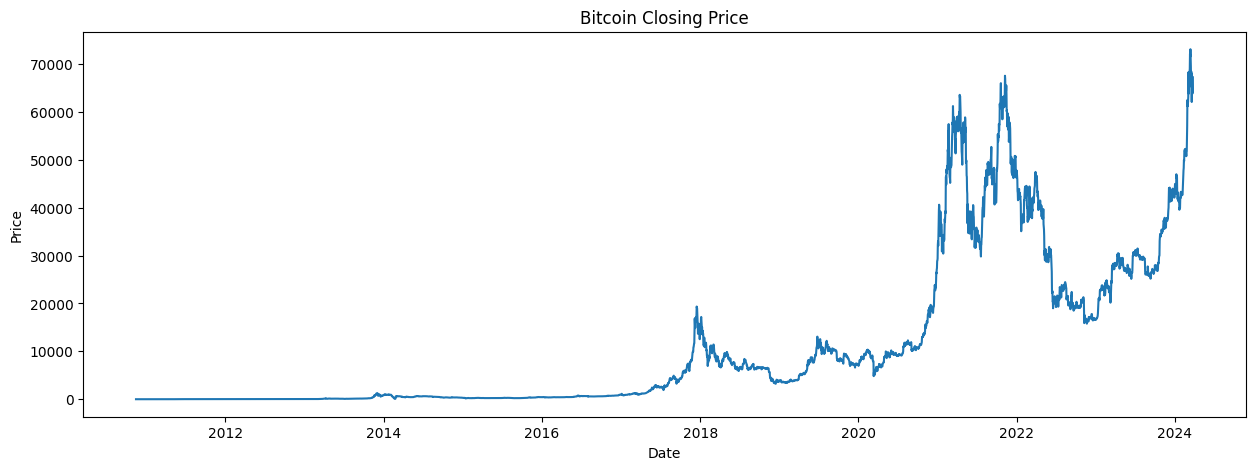

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Price"])

plt.title("Bitcoin Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

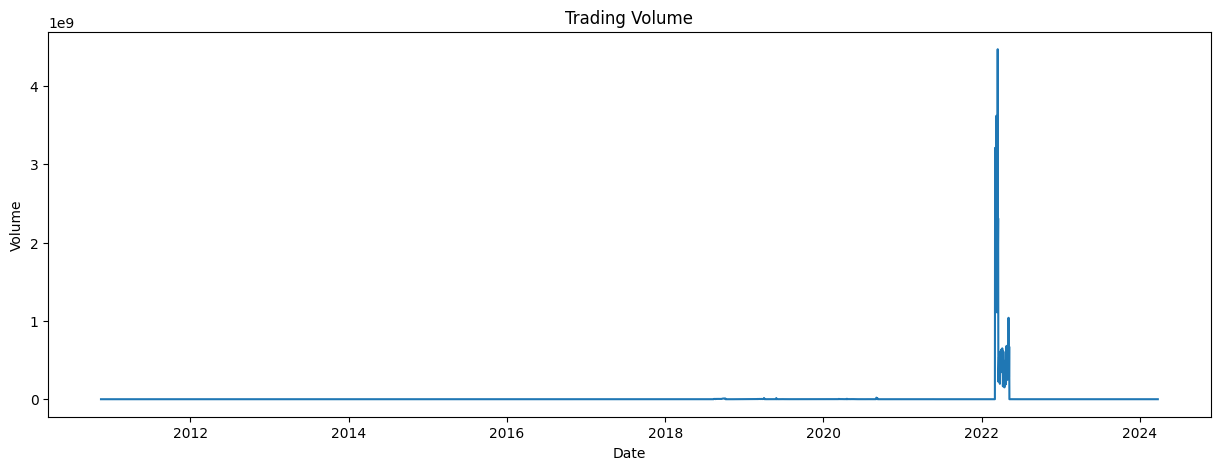

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Vol."])

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

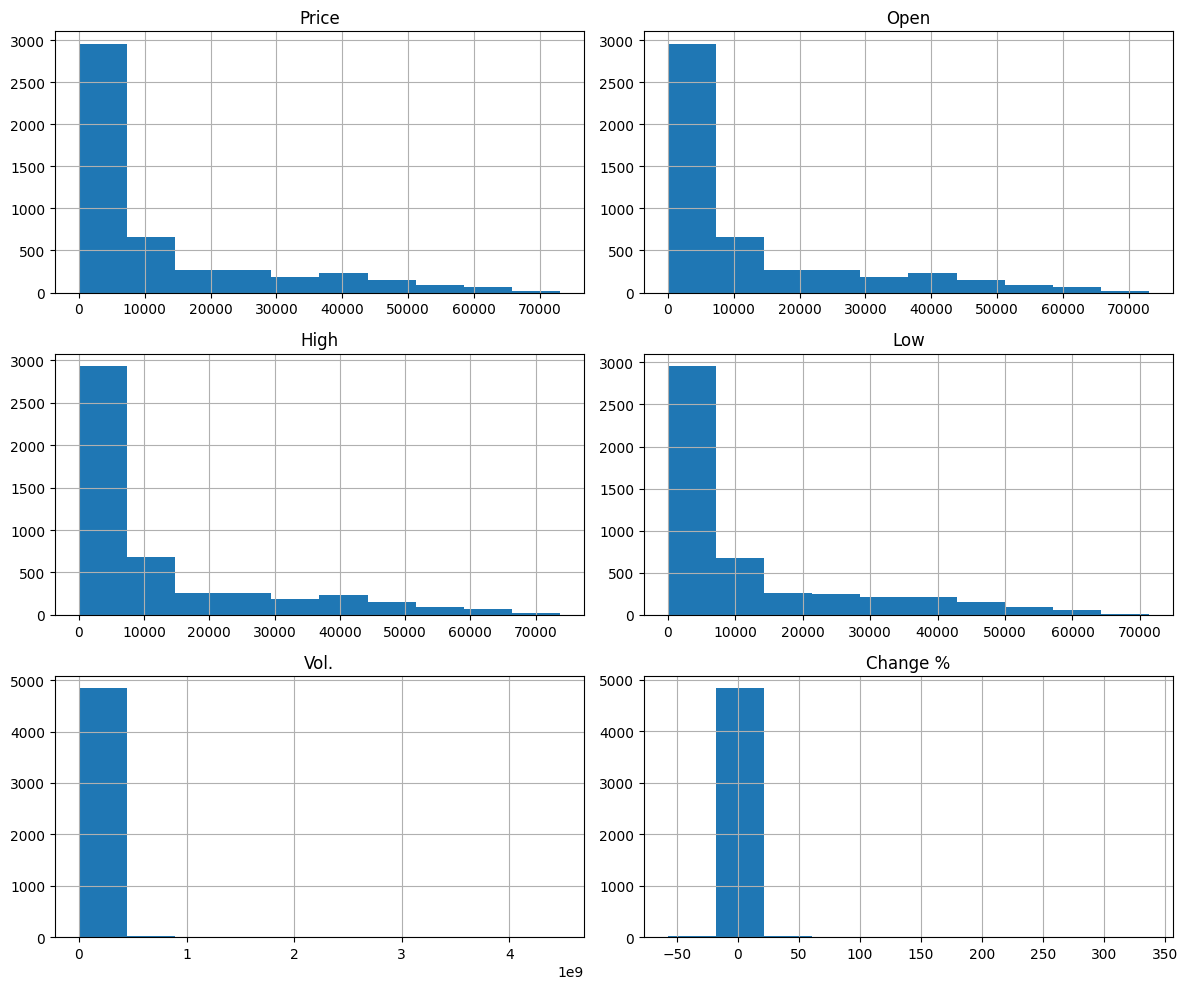

In [ ]:
df.drop("Date", axis=1).hist(figsize=(12,10))

plt.tight_layout()

plt.show()

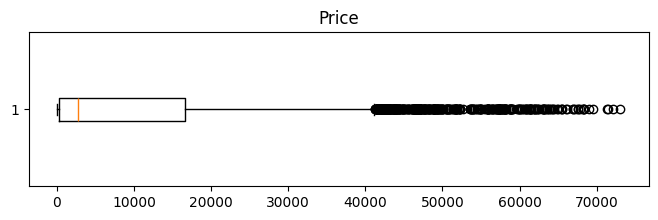

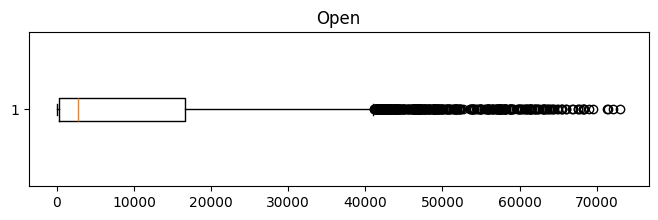

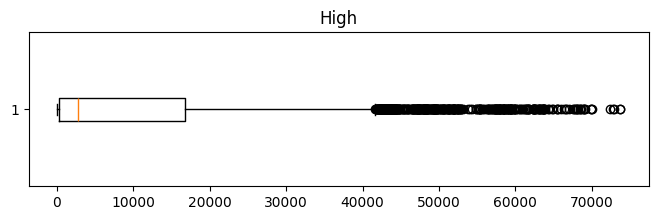

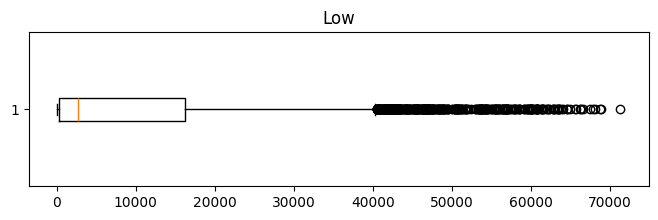

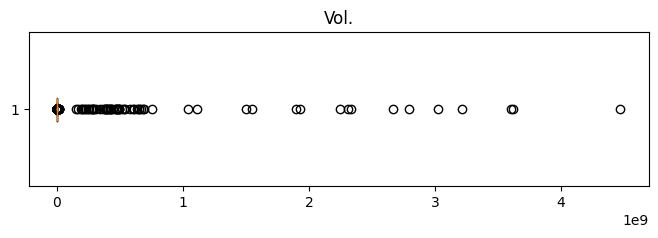

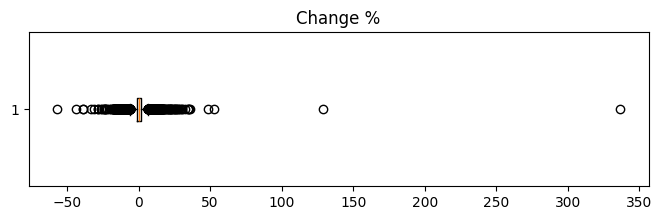

In [ ]:
numeric_cols = [
    "Price",
    "Open",
    "High",
    "Low",
    "Vol.",
    "Change %"
]

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [ ]:
df.to_csv(
    "/content/drive/MyDrive/CryptoCast/data/bitcoin_clean.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/CryptoCast"

DATA_PATH = os.path.join(PROJECT_PATH, "data")

print(DATA_PATH)

/content/drive/MyDrive/CryptoCast/data


In [ ]:
df = pd.read_csv(
    os.path.join(DATA_PATH, "bitcoin_clean.csv")
)

df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2010-11-15,0.3,0.3,0.3,0.3,8510.0,0.0
1,2010-11-16,0.2,0.3,0.3,0.2,33930.0,0.0
2,2010-11-17,0.2,0.2,0.3,0.2,32870.0,0.0
3,2010-11-18,0.3,0.2,0.3,0.2,37450.0,0.0
4,2010-11-19,0.3,0.3,0.3,0.3,2160.0,0.0


In [ ]:
data = df[["Price"]]

data.head()

,Price
0,0.3
1,0.2
2,0.2
3,0.3
4,0.3


In [ ]:
train_size = int(len(data) * 0.80)

train = data.iloc[:train_size]

test = data.iloc[train_size:]

print("Train Shape :", train.shape)

print("Test Shape :", test.shape)

Train Shape : (3903, 1)
Test Shape : (976, 1)


In [ ]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)

test_scaled = scaler.transform(test)

print(train_scaled.shape)

print(test_scaled.shape)

(3903, 1)
(976, 1)


In [ ]:
joblib.dump(
    scaler,
    os.path.join(PROJECT_PATH, "price_scaler.pkl")
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [ ]:
def create_sequences(data,
                     lookback,
                     horizon):

    X = []

    y = []

    for i in range(len(data)-lookback-horizon+1):

        X.append(
            data[
                i:i+lookback
            ]
        )

        y.append(
            data[
                i+lookback:
                i+lookback+horizon
            ].flatten()
        )

    return np.array(X), np.array(y)

In [ ]:
LOOKBACK = 60

In [ ]:
X_train_1d, y_train_1d = create_sequences(
    train_scaled,
    LOOKBACK,
    1
)

X_test_1d, y_test_1d = create_sequences(
    test_scaled,
    LOOKBACK,
    1
)

In [ ]:
X_train_3d, y_train_3d = create_sequences(
    train_scaled,
    LOOKBACK,
    3
)

X_test_3d, y_test_3d = create_sequences(
    test_scaled,
    LOOKBACK,
    3
)

In [ ]:
X_train_7d, y_train_7d = create_sequences(
    train_scaled,
    LOOKBACK,
    7
)

X_test_7d, y_test_7d = create_sequences(
    test_scaled,
    LOOKBACK,
    7
)

In [ ]:
print("========== 1-Day ==========")

print("X_train :", X_train_1d.shape)

print("y_train :", y_train_1d.shape)

print("X_test  :", X_test_1d.shape)

print("y_test  :", y_test_1d.shape)

print()

print("========== 3-Day ==========")

print("X_train :", X_train_3d.shape)

print("y_train :", y_train_3d.shape)

print("X_test  :", X_test_3d.shape)

print("y_test  :", y_test_3d.shape)

print()

print("========== 7-Day ==========")

print("X_train :", X_train_7d.shape)

print("y_train :", y_train_7d.shape)

print("X_test  :", X_test_7d.shape)

print("y_test  :", y_test_7d.shape)

========== 1-Day ==========
X_train : (3843, 60, 1)
y_train : (3843, 1)
X_test  : (916, 60, 1)
y_test  : (916, 1)

========== 3-Day ==========
X_train : (3841, 60, 1)
y_train : (3841, 3)
X_test  : (914, 60, 1)
y_test  : (914, 3)

========== 7-Day ==========
X_train : (3837, 60, 1)
y_train : (3837, 7)
X_test  : (910, 60, 1)
y_test  : (910, 7)


In [ ]:
np.save(os.path.join(DATA_PATH,"X_train_1d.npy"),X_train_1d)
np.save(os.path.join(DATA_PATH,"y_train_1d.npy"),y_train_1d)

np.save(os.path.join(DATA_PATH,"X_test_1d.npy"),X_test_1d)
np.save(os.path.join(DATA_PATH,"y_test_1d.npy"),y_test_1d)

np.save(os.path.join(DATA_PATH,"X_train_3d.npy"),X_train_3d)
np.save(os.path.join(DATA_PATH,"y_train_3d.npy"),y_train_3d)

np.save(os.path.join(DATA_PATH,"X_test_3d.npy"),X_test_3d)
np.save(os.path.join(DATA_PATH,"y_test_3d.npy"),y_test_3d)

np.save(os.path.join(DATA_PATH,"X_train_7d.npy"),X_train_7d)
np.save(os.path.join(DATA_PATH,"y_train_7d.npy"),y_train_7d)

np.save(os.path.join(DATA_PATH,"X_test_7d.npy"),X_test_7d)
np.save(os.path.join(DATA_PATH,"y_test_7d.npy"),y_test_7d)

print("All NumPy files saved successfully.")

All NumPy files saved successfully.


In [ ]:
files = sorted(os.listdir(DATA_PATH))

for file in files:

    print(file)

Bitcoin Historical Data (1).csv
X_test_1d.npy
X_test_3d.npy
X_test_7d.npy
X_train_1d.npy
X_train_3d.npy
X_train_7d.npy
bitcoin_clean.csv
y_test_1d.npy
y_test_3d.npy
y_test_7d.npy
y_train_1d.npy
y_train_3d.npy
y_train_7d.npy


**CNN MODEL**

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

**RNN MODEL**

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/CryptoCast"

DATA_PATH = os.path.join(PROJECT_PATH, "data")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "outputs")
MODEL_PATH = os.path.join(PROJECT_PATH, "saved_models")

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

In [ ]:
MODEL_NAME = "Transformer"
HORIZON = 7

In [ ]:
X_train = np.load(os.path.join(DATA_PATH, f"X_train_{HORIZON}d.npy"))
y_train = np.load(os.path.join(DATA_PATH, f"y_train_{HORIZON}d.npy"))

X_test = np.load(os.path.join(DATA_PATH, f"X_test_{HORIZON}d.npy"))
y_test = np.load(os.path.join(DATA_PATH, f"y_test_{HORIZON}d.npy"))

print(X_train.shape)
print(y_train.shape)

(3837, 60, 1)
(3837, 7)


In [ ]:
scaler = joblib.load(
    os.path.join(PROJECT_PATH, "price_scaler.pkl")
)

In [ ]:
model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(60,1)
    )
)

model.add(
    MaxPooling1D(pool_size=2)
)

model.add(
    Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu"
    )
)

model.add(
    Flatten()
)

model.add(
    Dense(64, activation="relu")
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(HORIZON)
)
model.compile(
    optimizer="adam",
    loss="mse"
)

**RNN**

In [ ]:
model = Sequential()

model.add(SimpleRNN(
    64,
    return_sequences=True,
    input_shape=(60,1)
))

model.add(Dropout(0.2))

model.add(SimpleRNN(32))

model.add(Dense(32, activation="relu"))

model.add(Dense(HORIZON))

model.compile(
    optimizer="adam",
    loss="mse"
)

LSTM MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(60, 1)
    )
)

model.add(Dropout(0.2))

# Second LSTM layer
model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

# Dense layer
model.add(
    Dense(32, activation="relu")
)

# Output layer
model.add(
    Dense(HORIZON)
)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,599 (119.53 KB)

 Trainable params: 30,599 (119.53 KB)

 Non-trainable params: 0 (0.00 B)

**TRANSFORMER**

In [ ]:
import tensorflow as tf
inputs = Input(shape=(LOOKBACK, 1))

# Project input
x = Dense(64)(inputs)

# Encoder Block 1
attn = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(x, x)

x = Add()([x, attn])
x = LayerNormalization()(x)

ffn = Dense(128, activation="relu")(x)
ffn = Dense(64)(ffn)

x = Add()([x, ffn])
x = LayerNormalization()(x)

# Flatten instead of GlobalAveragePooling
x = tf.keras.layers.Flatten()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)

outputs = Dense(HORIZON)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="mse"
)

NameError: name 'Input' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, sequence_length, d_model):
        super().__init__()

        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model
        )

    def call(self, x):

        positions = tf.range(start=0,
                             limit=tf.shape(x)[1],
                             delta=1)

        position_embeddings = self.position_embedding(positions)

        return x + position_embeddings

In [ ]:
def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0.1):

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)

    x = Add()([inputs, x])

    x = LayerNormalization(epsilon=1e-6)(x)

    y = Dense(ff_dim, activation="relu")(x)

    y = Dropout(dropout)(y)

    y = Dense(inputs.shape[-1])(y)

    x = Add()([x, y])

    x = LayerNormalization(epsilon=1e-6)(x)

    return x

In [ ]:
inputs = Input(shape=(LOOKBACK,1))

x = Dense(64)(inputs)

x = PositionalEncoding(
    LOOKBACK,
    64
)(x)

x = transformer_encoder(
    x,
    head_size=32,
    num_heads=4,
    ff_dim=128,
    dropout=0.1
)

x = transformer_encoder(
    x,
    head_size=32,
    num_heads=4,
    ff_dim=128,
    dropout=0.1
)

x = GlobalAveragePooling1D()(x)

x = Dense(64,activation="relu")(x)

x = Dropout(0.2)(x)

outputs = Dense(HORIZON)(x)

model = Model(inputs,outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="mse"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 60, 64)    │      3,840 │ dense_7[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     33,216 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 60, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 60, 64)    │          0 │ positional_encod… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 60, 128)   │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 60, 64)    │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 60, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 60, 128)   │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 60, 64)    │      8,256 │ dropout_12[0][0]

 Total params: 108,679 (424.53 KB)

 Trainable params: 108,679 (424.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop,checkpoint],
    verbose=1
)

Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - loss: 0.0158 - val_loss: 0.0621
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 9.4822e-04 - val_loss: 0.0549
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 8.0581e-04 - val_loss: 0.0584
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 7.1086e-04 - val_loss: 0.0615
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 6.9362e-04 - val_loss: 0.0620
Epoch 6/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 6.6052e-04 - val_loss: 0.0560
Epoch 7/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 6.3469e-04 - val_loss: 0.0584
Epoch 8/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 6.0961e-04 - val_loss: 0.0585
Epoch 9/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 5.5634e-04 - val_loss: 0.0559
Epoch 10/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 5.4680e-04 - val_loss: 0.0494
Epoch 11/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 5.1315e-04 - val_loss: 0.0648
Epoch 12/

In [ ]:
model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 60, 64)    │        128 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 64)    │     16,640 │ dense_19[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 60, 64)    │          0 │ dense_19[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 60, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 60, 64)    │      8,256 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 60, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3840)      │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │    491,648 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1)         │         65 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 533,569 (2.04 MB)

 Trainable params: 533,569 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    os.path.join(
        MODEL_PATH,
        f"{MODEL_NAME}_{HORIZON}d.keras"
    ),
    save_best_only=True
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    os.path.join(
        MODEL_PATH,
        f"{MODEL_NAME}_{HORIZON}d.keras"
    ),
    save_best_only=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0731 - val_loss: 0.0962
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0020 - val_loss: 0.1076
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 7.3675e-04 - val_loss: 0.0803
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 4.3659e-04 - val_loss: 0.0827
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 3.8422e-04 - val_loss: 0.0791
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 3.9141e-04 - val_loss: 0.0851
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 3.5737e-04 - val_loss: 0.0773
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 3.1605e-04 - val_loss: 0.0840
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 3.3740e-04 - val_loss: 0.0856
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 3.5195e-04 - val_loss: 0.0912
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2.7289e-04 - val_loss: 0.0825
Epoch 12/50
97/97 ━━━━━━━━━

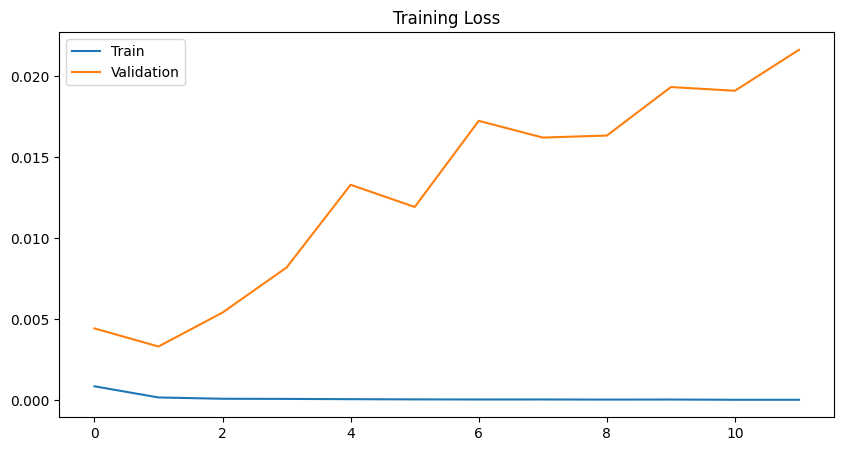

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train")

plt.plot(history.history["val_loss"], label="Validation")

plt.title("Training Loss")

plt.legend()

plt.show()

In [ ]:
pred = model.predict(X_test)

print(pred.shape)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
(910, 7)


In [ ]:
pred_price = scaler.inverse_transform(pred)

actual_price = scaler.inverse_transform(y_test)

In [ ]:
mae = mean_absolute_error(
    actual_price.flatten(),
    pred_price.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actual_price.flatten(),
        pred_price.flatten()
    )
)

mape = mean_absolute_percentage_error(
    actual_price.flatten(),
    pred_price.flatten()
) * 100

r2 = r2_score(
    actual_price.flatten(),
    pred_price.flatten()
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 14673.33
RMSE : 19186.95
MAPE : 36.80%
R²   : -1.1690


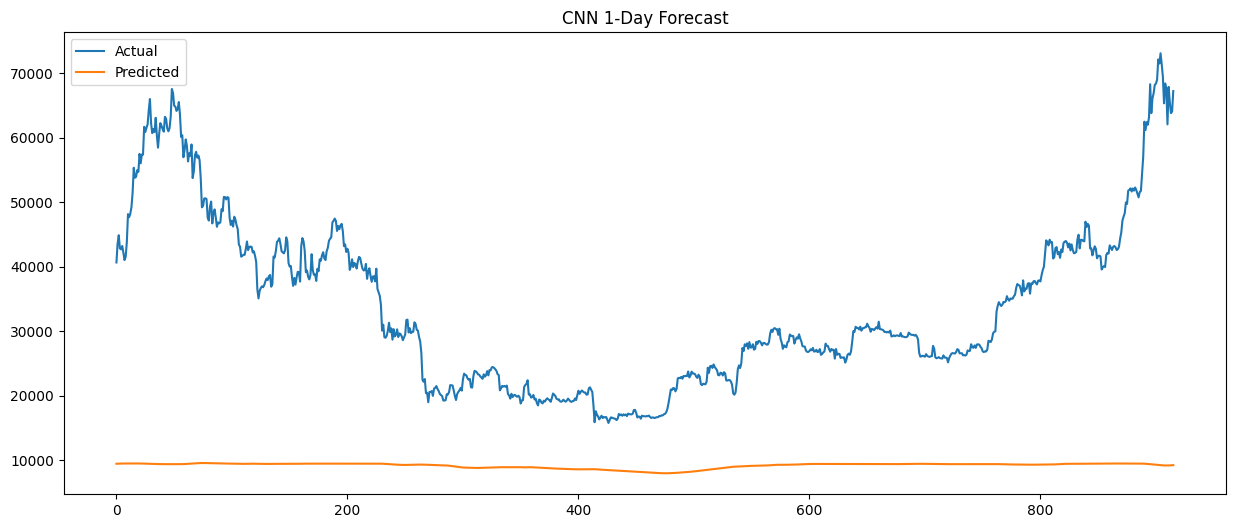

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(actual_price[:,0], label="Actual")

plt.plot(pred_price[:,0], label="Predicted")

plt.title(f"CNN {HORIZON}-Day Forecast")

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame()

for i in range(HORIZON):

    results[f"Actual_Day{i+1}"] = actual_price[:,i]

    results[f"Predicted_Day{i+1}"] = pred_price[:,i]

results.to_csv(
    os.path.join(OUTPUT_PATH, f"{MODEL_NAME}_{HORIZON}d_Predictions.csv"),
    index=False
)
results.head()

,Actual_Day1,Predicted_Day1,Actual_Day2,Predicted_Day2,Actual_Day3,Predicted_Day3,Actual_Day4,Predicted_Day4,Actual_Day5,Predicted_Day5,Actual_Day6,Predicted_Day6,Actual_Day7,Predicted_Day7
0,40651.3,21361.921875,43551.6,23128.156250,44869.2,19442.390625,42819.9,15704.659180,42686.8,16812.464844,43203.4,19532.261719,42172.6,22676.314453
1,43551.6,21428.582031,44869.2,23029.191406,42819.9,19489.710938,42686.8,15713.870117,43203.4,16850.695312,42172.6,19482.919922,41022.3,22632.179688
2,44869.2,21400.949219,42819.9,22979.990234,42686.8,19485.925781,43203.4,15581.448242,42172.6,16781.964844,41022.3,19482.560547,41536.8,22621.865234
3,42819.9,21408.355469,42686.8,23013.490234,43203.4,19502.341797,42172.6,15558.227539,41022.3,16832.632812,41536.8,19469.539062,43823.3,22706.470703
4,42686.8,21337.185547,43203.4,23086.867188,42172.6,19516.974609,41022.3,15542.525391,41536.8,16877.263672,43823.3,19440.982422,48146.0,22783.312500


In [ ]:
metrics = pd.DataFrame({
    "Model": [MODEL_NAME],
    "Horizon": [f"{HORIZON}-Day"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

metrics.to_csv(
    os.path.join(OUTPUT_PATH, f"{MODEL_NAME}_{HORIZON}d_Metrics.csv"),
    index=False
)
metrics

,Model,Horizon,MAE,RMSE,MAPE,R2
0,Transformer,7-Day,14673.326541,19186.948571,36.804695,-1.168983


In [ ]:
print(X_train.shape)
print(y_train.shape)

(3843, 60, 1)
(3843, 1)


In [ ]:
len(history.history['loss'])

12

| Model           | Horizon |         MAE |        RMSE |      MAPE |         R² |
| --------------- | ------- | ----------: | ----------: | --------: | ---------: |
| **CNN**         | 1-Day   | **1205.77** | **1717.56** | **3.50%** | **0.9829** |
| **CNN**         | 3-Day   |     3472.47 |     4413.14 |     9.40% |     0.8864 |
| **CNN**         | 7-Day   | **3475.49** | **4633.84** | **9.54%** | **0.8735** |
| **RNN**         | 1-Day   |     4784.32 |     6310.72 |    12.19% |     0.7688 |
| **RNN**         | 3-Day   |    10486.12 |    14011.72 |    25.84% |    -0.1456 |
| **RNN**         | 7-Day   |     7288.11 |    10388.15 |    17.39% |     0.3642 |
| **LSTM**        | 1-Day   |     3112.13 |     4608.81 |     7.82% |     0.8767 |
| **LSTM**        | 3-Day   | **2283.75** | **3550.24** | **5.73%** | **0.9265** |
| **LSTM**        | 7-Day   |     4212.19 |     5933.54 |    10.57% |     0.7926 |
| **Transformer** | 1-Day   |    11004.73 |    14938.84 |    26.85% |    -0.2957 |
| **Transformer** | 3-Day   |    19516.51 |    25393.35 |    51.62% |    -2.7626 |
| **Transformer** | 7-Day   |    14673.33 |    19186.95 |    36.80% |    -1.1690 |
**bold text**

Best Model by Horizon
Horizon	Best Model	R²

1-Day	🥇 CNN	0.9829

3-Day	🥇 LSTM	0.9265

7-Day	🥇 CNN	0.8735

Interpretation

CNN
Best for 1-Day forecasting.
Best for 7-Day forecasting.
Lowest prediction errors overall.

LSTM
Best for 3-Day forecasting.
Better than RNN across all horizons.
Suitable for capturing medium-term temporal dependencies.

RNN
Performed reasonably for 1-Day.
Performance degraded for 3-Day and 7-Day due to the limitations of SimpleRNNs.

Transformer
Performed poorly across all horizons.
Negative R² values indicate it failed to generalize well on this dataset.
This is acceptable and can be explained by the relatively small, univariate dataset.